In [1]:
import json
import pandas as pd
from matplotlib import pyplot as plt
import os
from typing import Union, Literal
import numpy as np
from scipy.stats import pearsonr, spearmanr


ALL_LANGUAGES = ['af', 'am', 'ar', 'az', 'bg', 'bn', 'cs', 'da', 'de', 'el', 'en', 'es', 'fa', 'fi', 'fr', 'he',
                 'hi', 'hu', 'hy', 'id', 'is', 'it', 'ja', 'jv', 'ka', 'km', 'kn', 'ko', 'lt', 'ml', 'mr', 'nl',
                 'pl', 'pt', 'ru', 'sw', 'ta', 'te', 'th', 'tl', 'tr', 'ur', 'vi', 'zh']

In [2]:
MODEL="Qwen3-14B"

# METRIC="anc"
# METRIC="cosine"
# METRIC="dist"
# METRIC="ratio"
METRIC="nn-abs"

# SENT_REP="fewshot"
# SENT_REP="mean"
# SENT_REP = "last-token"
SENT_REP = "weighted-mean"

with open(os.path.join("..", "scores", "flores", f"{MODEL}_{SENT_REP}_{METRIC}.json")) as f:
    cla_scores = json.load(f)

# with open(os.path.join("..", "scores", "sib-200", f"{MODEL}.json")) as f:
#     sib_scores = json.load(f)

In [3]:
MODEL="Qwen3-14B"

METRICS = ["anc", "cosine", "nn-abs", "dist", "ratio", "dali"]#, "eflomal"]
SENT_REPS = ["fewshot", "mean", "prompt", "last-token", "weighted-mean"]

cla_all = dict()

for metric in METRICS:
    cla_all[metric] = dict()
    for sent_rep in SENT_REPS:

        if metric == "dali":
            if sent_rep == "last-token":
                with open(f"../scores/dali_belebele/{MODEL}.json") as f:
                    cla_all[metric][sent_rep] = json.load(f)
            continue

        if metric == "eflomal":
            if sent_rep == "mean":
                with open(os.path.join("..", "scores", "eflomal", f"{MODEL}.json")) as f:
                    eflomal_dict = json.load(f)
                eflomal_scores = dict()
                for lang1, record in eflomal_dict.items():
                    for lang2, values in record.items():
                        eflomal_scores[f"{lang1}-{lang2}"] = [-values["eflomal"]]
                cla_all[metric][sent_rep] = eflomal_scores

        if os.path.isfile(os.path.join("..", "scores", "flores", f"{MODEL}_{sent_rep}_{metric}.json")):
            with open(os.path.join("..", "scores", "flores", f"{MODEL}_{sent_rep}_{metric}.json")) as f:
                cla_all[metric][sent_rep] = json.load(f)

In [4]:
with open(os.path.join("..", "scores", "dali_belebele", f"{MODEL}.json")) as f:
    dali_scores = json.load(f)

dali_langs = list({key[:2] for key in dali_scores})
dali_langs.sort()

In [5]:
def get_alignment(source_lang: str, target_lang: str = "MEAN", exclude_targets = [], layer: Union[int, Literal["HIGHEST", "MEAN"]] = "MEAN", cla=cla_scores, return_layer = False):
    if target_lang != "MEAN":
        if target_lang == source_lang:
            return 1
        layer_scores = cla[f"{source_lang}-{target_lang}"]
        if layer == "HIGHEST":
            return max(layer_scores) if not return_layer else (max(layer_scores), np.argmax(layer_scores))
        if layer == "MEAN":
            return sum(layer_scores)/len(layer_scores)
        return layer_scores[layer]
    
    targ_langs = set(ALL_LANGUAGES).difference(exclude_targets)
    aligments_matrix = np.empty((len(targ_langs), len(cla["af-am"])))
    for i, tgt_lang in enumerate(targ_langs):
        if tgt_lang == source_lang:
            continue
        aligments_matrix[i] = cla[f"{source_lang}-{tgt_lang}"]
    mean_scores = aligments_matrix.mean(axis=0)
    if layer == "HIGHEST":
        return max(mean_scores) if not return_layer else (max(mean_scores), np.argmax(mean_scores))
    if layer == "MEAN":
        return mean_scores.mean()
    
    return mean_scores[layer]

In [6]:
def get_best_aligned_layer(cla=cla_scores):
    alignments = np.array(list(cla.values()))
    mean_align = alignments.mean(axis=0)
    return mean_align.argmax()

BEST_LAYER = get_best_aligned_layer()

In [7]:
best_layers_all = dict()

for metric in METRICS:
    best_layers_all[metric] = dict()
    for sent_rep in SENT_REPS:
        try:
            best_layers_all[metric][sent_rep] = get_best_aligned_layer(cla_all[metric][sent_rep])
        except KeyError:
            continue

In [8]:
with open("../scores/sib-200/Qwen3-14B.json") as f:
    sib_scores = json.load(f)

mean_df = pd.DataFrame({
    "langs": ALL_LANGUAGES,
    "alinments": [get_alignment(lang, layer=BEST_LAYER) for lang in ALL_LANGUAGES],
    "alinments-mean": [get_alignment(lang, layer="MEAN") for lang in ALL_LANGUAGES],
    "sib": [sib_scores[lang] for lang in ALL_LANGUAGES]
})

FileNotFoundError: [Errno 2] No such file or directory: '../scores/sib-200/Qwen3-14B.json'

In [8]:
plt.plot(mean_df["alinments"], mean_df["sib"], "o")
plt.xlabel(f"{METRIC} CLA (layer {BEST_LAYER})")
plt.ylabel("SIB-200 score")
plt.show()
print(pearsonr(mean_df["alinments"], mean_df["sib"]))

NameError: name 'mean_df' is not defined

In [9]:
plt.plot(mean_df["alinments-mean"], mean_df["sib"], "o")
plt.xlabel(f"{METRIC} CLA (layer average)")
plt.ylabel("SIB-200 score")
plt.show()
print(pearsonr(mean_df["alinments-mean"], mean_df["sib"]))

NameError: name 'mean_df' is not defined

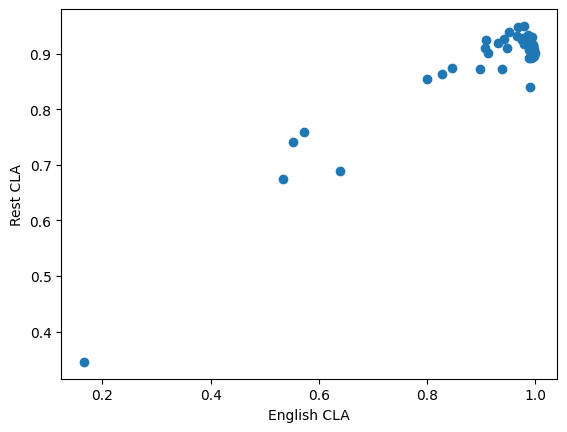

PearsonRResult(statistic=np.float64(0.9388844631878656), pvalue=np.float64(1.348538491565222e-20))


In [8]:
ALL_LANGUAGES_NO_EN = ALL_LANGUAGES.copy()
ALL_LANGUAGES_NO_EN.remove("en")

alignment_en_vs_rest = pd.DataFrame({
    "langs": ALL_LANGUAGES_NO_EN,
    "en": [get_alignment(lang, "en", layer=BEST_LAYER) for lang in ALL_LANGUAGES_NO_EN],
    "rest": [get_alignment(lang, exclude_targets=["en"], layer=BEST_LAYER) for lang in ALL_LANGUAGES_NO_EN]
})

plt.plot(alignment_en_vs_rest["en"], alignment_en_vs_rest["rest"], "o")
plt.xlabel("English CLA")
plt.ylabel("Rest CLA")
plt.show()

print(pearsonr(alignment_en_vs_rest["en"], alignment_en_vs_rest["rest"]))

## ChrF vs. Mutinf vs. COMET

In [9]:
with open("../scores/translation_mutinf/Qwen3-14B.json") as f:
    mutinfs = json.load(f)
    mutinfs_lp_mean = {k: v["mean"] for k, v in mutinfs.items()}
    mutinfs_lp_sentl = {k: v["sentence-level"] for k, v in mutinfs.items()}

with open(os.path.join("..", "scores", "translation_chrf", "Qwen3-14B.json")) as f:
    chrf = json.load(f)
    chrf_lp_mean = {k: v["mean"] for k, v in chrf.items()}
    chrf_lp_sentl = {k: v["sentence-level"] for k, v in chrf.items()}

with open(os.path.join("..", "scores", "comet", "Qwen3-14B.json")) as f:
    comet = json.load(f)
    comet_lp_mean = {k: v["mean"] for k, v in comet.items()}
    comet_lp_sentl = {k: v["sentence-level"] for k, v in comet.items()}

In [10]:
corrs_comet_chrf = [pearsonr(comet_lp_sentl[lp], chrf_lp_sentl[lp]).correlation for lp in comet_lp_sentl]
corrs_comet_mutinf = [pearsonr(comet_lp_sentl[lp], mutinfs_lp_sentl[lp]).correlation for lp in comet_lp_sentl]
corrs_chrf_mutinf = [pearsonr(chrf_lp_sentl[lp], mutinfs_lp_sentl[lp]).correlation for lp in comet_lp_sentl] 

print("COMET vs. ChrF correlation (per language pair average):", np.mean(corrs_comet_chrf))
print("COMET vs. PMI correlation (per language pair average):", np.mean(corrs_comet_mutinf))
print("PMI vs. ChrF correlation (per language pair average):", np.mean(corrs_chrf_mutinf))

pearsonr(chrf_lp_sentl["es-en"], mutinfs_lp_sentl["es-en"])

ValueError: `x` and `y` must be broadcastable.

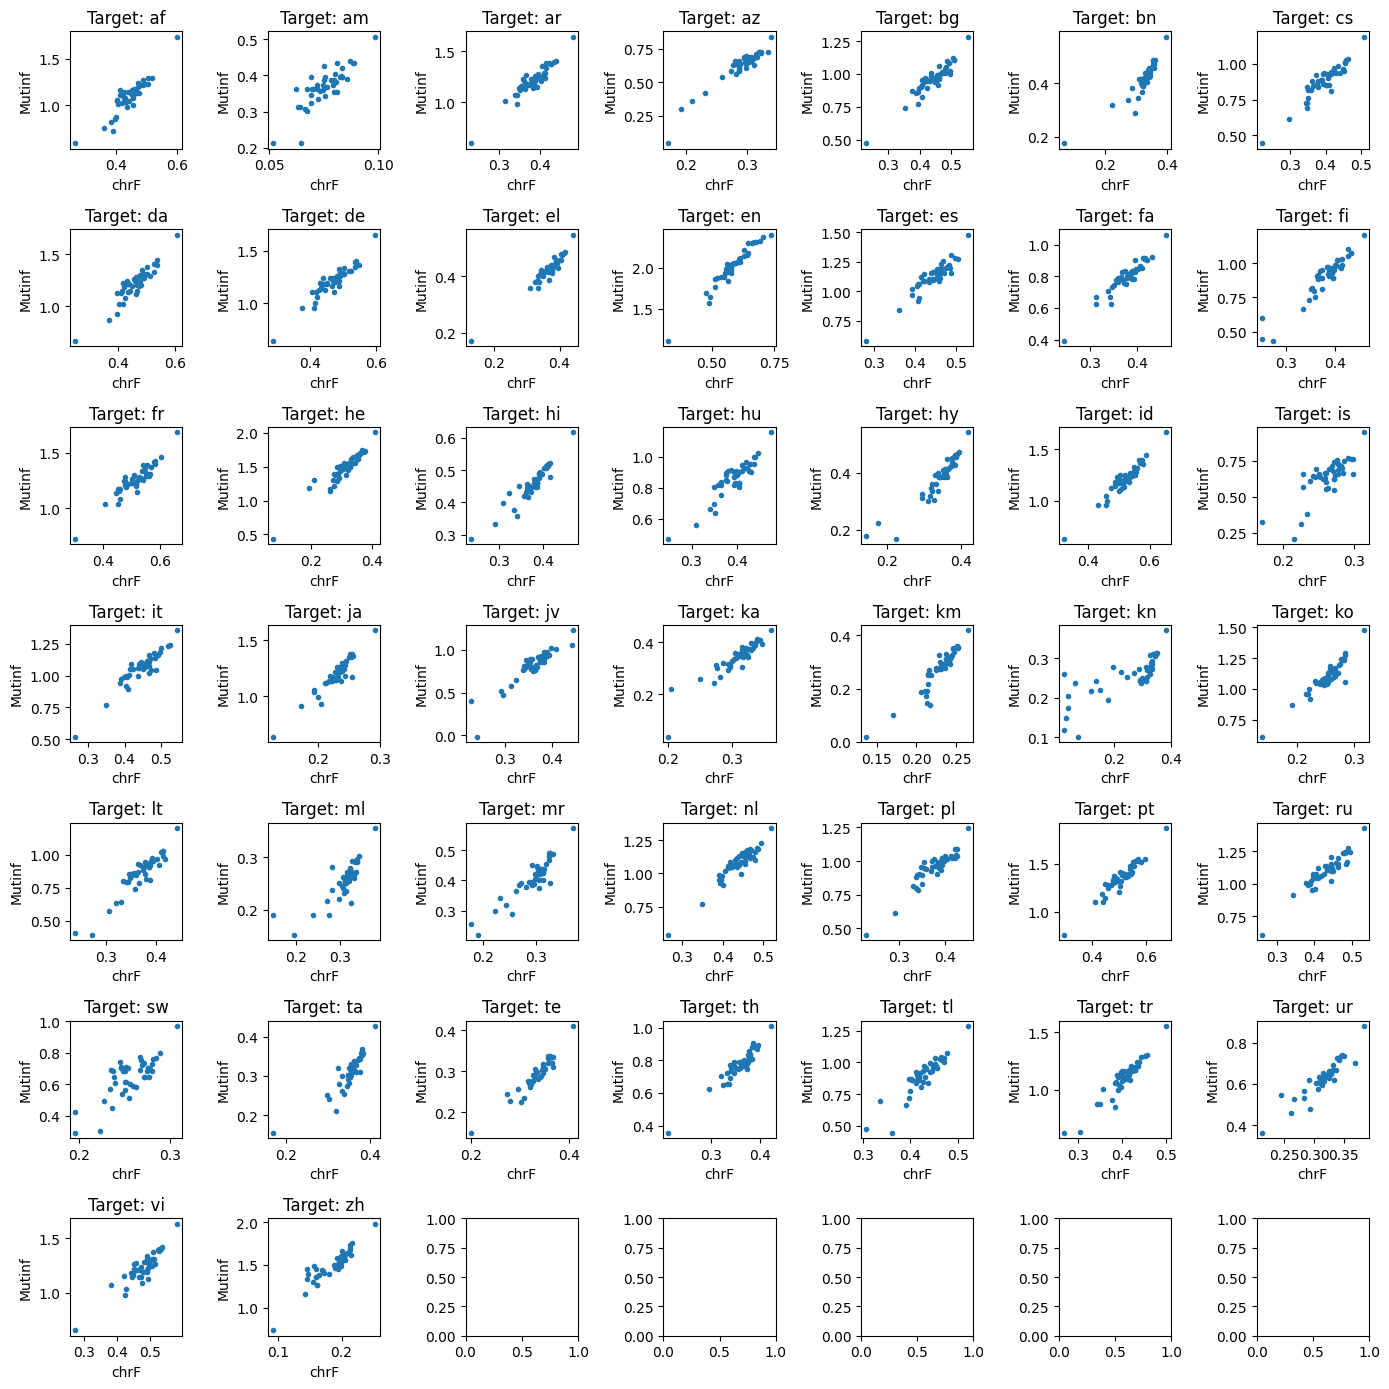

Correlation, per target language mean: 0.9196078468700315


In [11]:
lang_pairs = list(chrf.keys())

# compute the correlations within a target language and compute the average
fig, axes = plt.subplots(7, 7, figsize=(14,14))
correlations = []
for i, tgt_lang in enumerate(ALL_LANGUAGES):
    mutinfs_tgt = [mutinfs_lp_mean[f"{src_lang}-{tgt_lang}"] for src_lang in ALL_LANGUAGES if src_lang not in [tgt_lang]]#[get_alignment(src_lang, "en", layer=5, cla=cla_all["ratio"]["last-token"]) for src_lang in ALL_LANGUAGES if src_lang not in ("en", tgt_lang)]
    metric_tgt = [chrf_lp_mean[f"{src_lang}-{tgt_lang}"] for src_lang in ALL_LANGUAGES if src_lang not in [tgt_lang]]
    correlations.append(pearsonr(metric_tgt, mutinfs_tgt)[0])
    ax = axes.flatten()[i]
    ax.plot(metric_tgt, mutinfs_tgt, "o", markersize=3)
    ax.set_xlabel("chrF")
    ax.set_ylabel("Mutinf")
    ax.set_title("Target: " + tgt_lang)

plt.tight_layout()
plt.show()

print("Correlation, per target language mean:", np.mean(correlations))

## Mutinf vs. CLA

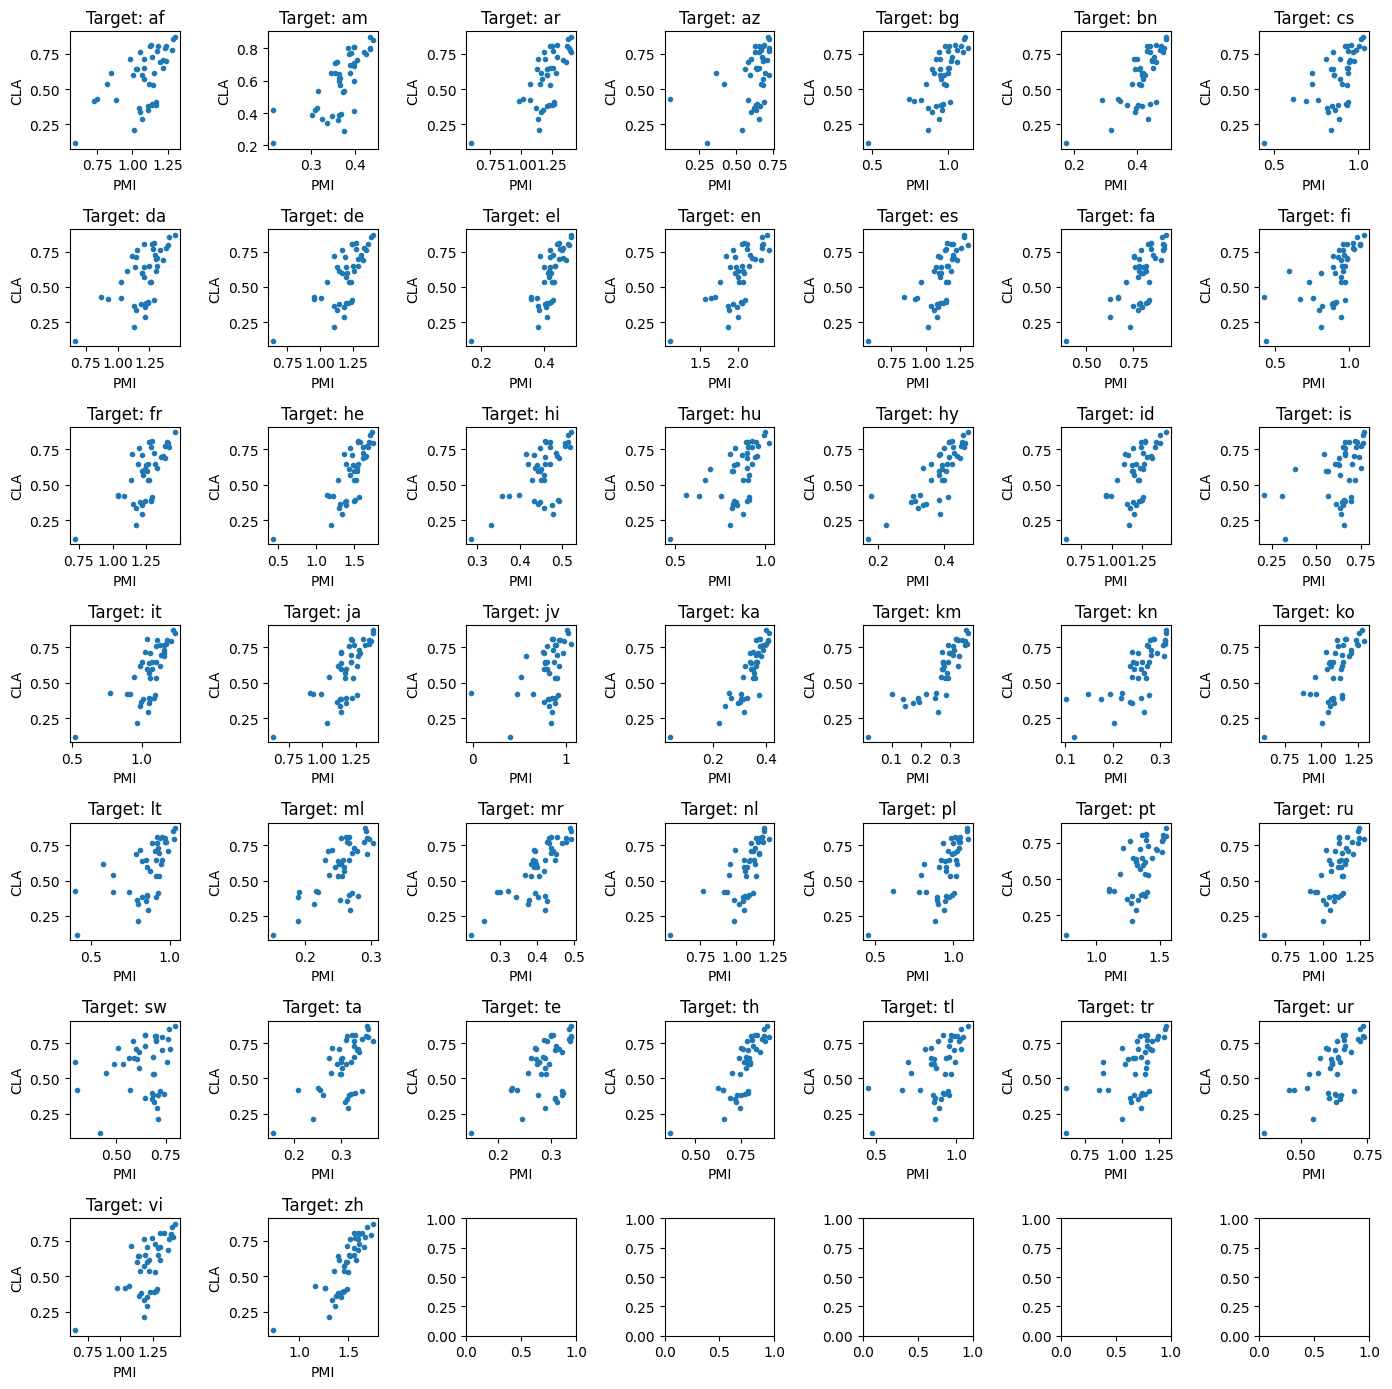

Correlation, per target language mean: 0.6606066903938591


In [12]:
cla_dict = cla_all["nn-abs"]["fewshot"]

# compute the correlations within a target language and compute the average
fig, axes = plt.subplots(7, 7, figsize=(14,14))
correlations = []
for i, tgt_lang in enumerate(ALL_LANGUAGES):
    alignments_tgt = [get_alignment(src_lang, "en", layer="MEAN", cla=cla_dict) for src_lang in ALL_LANGUAGES if src_lang not in ("en", tgt_lang)]
    pmi_tgt = [mutinfs_lp_mean[f"{src_lang}-{tgt_lang}"] for src_lang in ALL_LANGUAGES if src_lang not in ("en", tgt_lang)]
    correlations.append(pearsonr(pmi_tgt, alignments_tgt)[0])
    ax = axes.flatten()[i]
    ax.plot(pmi_tgt, alignments_tgt, "o", markersize=3)
    ax.set_xlabel("PMI")
    ax.set_ylabel("CLA")
    ax.set_title("Target: " + tgt_lang)

plt.tight_layout()
plt.show()

print("Correlation, per target language mean:", np.mean(correlations))

/tmp/ipykernel_1660166/3782486392.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_1660166/3782486392.py:67: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_alphas.show()


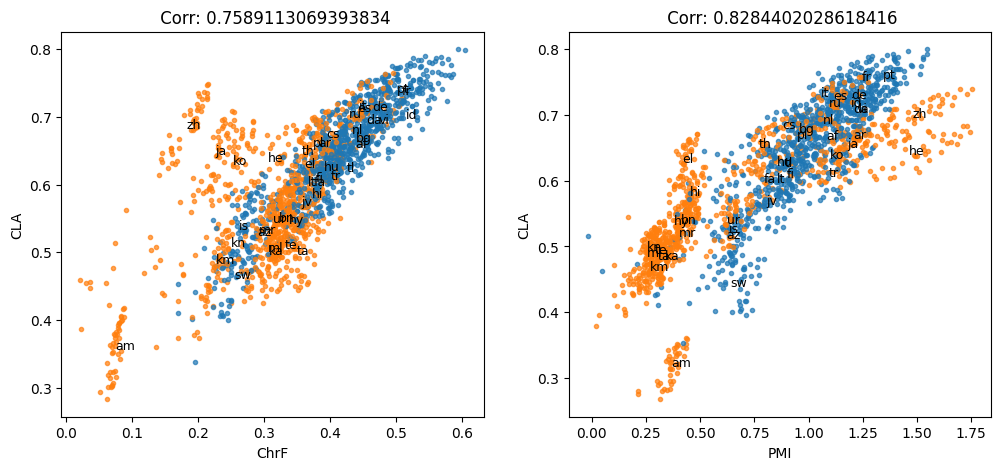

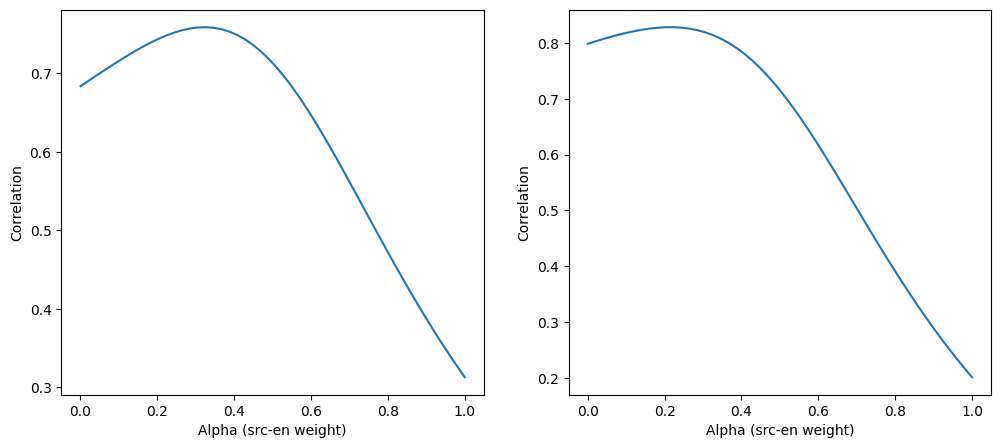

In [18]:
from langcodes import Language

def get_flores_code(short_code: str):
    lang = Language.get(short_code)
    script = lang.script or lang.assume_script().script
    return "arb_Arab" if short_code == "ar" \
        else "zho_Hant" if short_code == "zh" \
        else "azj_Latn" if short_code == "az" \
        else "pes_Arab" if short_code == "fa" \
        else "jav_Latn" if short_code == "jv" \
        else "kor_Hang" if short_code == "ko" \
        else "tgl_Latn" if short_code == "tl" \
        else "swh_Latn" if short_code == "sw" else f"{lang.to_alpha3()}_{script}"

metrics = {
    "ChrF": chrf_lp_mean,
    "PMI": mutinfs_lp_mean
}

sent_rep_ = "weighted-mean"
cla_metric = "anc"

fig, ax = plt.subplots(1, 2, figsize = (12,5))
fig_alphas, ax_alphas = plt.subplots(1, 2, figsize = (12,5))
for metric_idx, (name, metric) in enumerate(metrics.items()):
    lang_pairs = [lp for lp in metric.keys() if "en" not in lp and "cy" not in lp]
    mi_scores = [metric[lp] for lp in lang_pairs]
    corrs = []
    linspace = np.linspace(0,1,50)
    for alpha in linspace:
        alignments = [alpha * get_alignment(lng_pair[:2], "en", layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_]) 
                    + (1-alpha) * get_alignment("en", lng_pair[3:], layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_])
                    for lng_pair in lang_pairs]
        corrs.append(pearsonr(mi_scores, alignments).correlation)
    
    best_corr = np.nanmax(corrs)
    best_alpha = linspace[np.nanargmax(corrs)]

    import seaborn as sns
    colors = sns.color_palette("husl",44)

    for i, tgt_lang in enumerate(ALL_LANGUAGES):
        if tgt_lang == "en":
            continue
        _, script = get_flores_code(tgt_lang).split("_")
        if script == "Latin":
            continue
        best_alignments_tgt = [best_alpha * get_alignment(src_lang, "en", layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_]) 
                        + (1-best_alpha) * get_alignment("en", tgt_lang, layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_])
                        for src_lang in ALL_LANGUAGES if src_lang not in (tgt_lang, "en")]
        mi_scores_tgt = [metric[f"{src_lang}-{tgt_lang}"] for src_lang in ALL_LANGUAGES if src_lang not in (tgt_lang, "en")]
        ax[metric_idx].plot(mi_scores_tgt, best_alignments_tgt, "o", markersize=3, color="tab:blue" if script=="Latn" else "tab:orange", alpha=0.7)
        centroid = (np.mean(mi_scores_tgt), np.mean(best_alignments_tgt))
        ax[metric_idx].text(*centroid, tgt_lang, fontsize=9, zorder=10)
    ax[metric_idx].set_xlabel(name)
    ax[metric_idx].set_ylabel("CLA")
    best_alignments = [best_alpha * get_alignment(lng_pair[:2], "en", layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_]) 
                    + (1-best_alpha) * get_alignment("en", lng_pair[3:], layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_])
                    for lng_pair in lang_pairs]
    ax[metric_idx].set_title(f" Corr: {pearsonr(mi_scores, best_alignments).correlation}")

    ax_alphas[metric_idx].plot(linspace, corrs)
    ax_alphas[metric_idx].set_xlabel("Alpha (src-en weight)")
    ax_alphas[metric_idx].set_ylabel("Correlation")

fig.show()
fig_alphas.show()

/tmp/ipykernel_1660166/2279990230.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_1660166/2279990230.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_alphas.show()


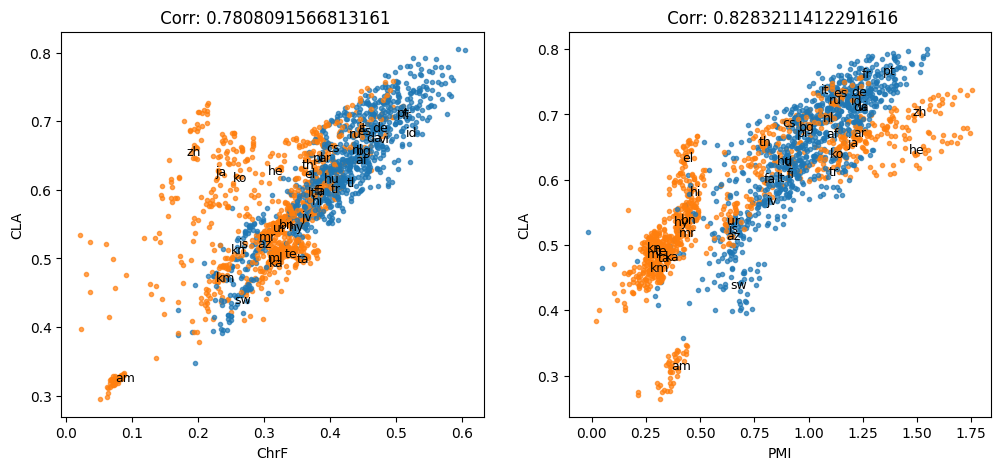

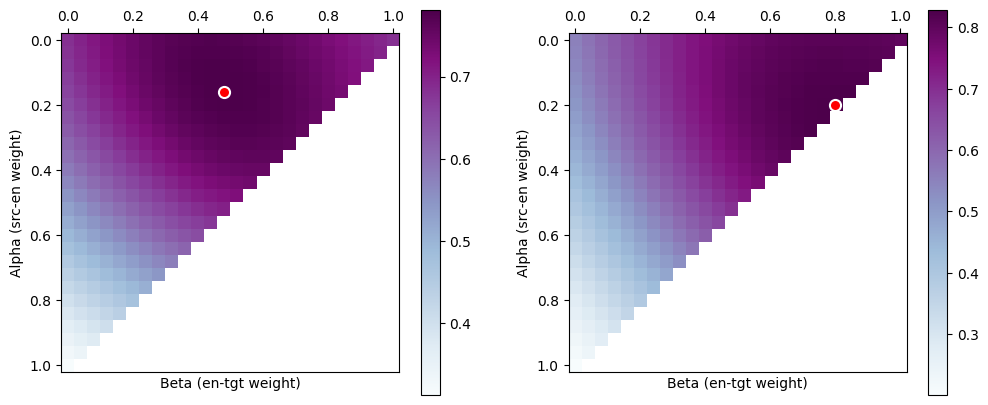

In [19]:
fig, ax = plt.subplots(1, 2, figsize = (12,5))
fig_alphas, ax_alphas = plt.subplots(1, 2, figsize = (12,5))
for metric_idx, (name, metric) in enumerate(metrics.items()):
    lang_pairs = [lp for lp in metric.keys() if "en" not in lp and "cy" not in lp]
    mi_scores = [metric[lp] for lp in lang_pairs]
    STEPS = 25
    corrs = np.ones((STEPS + 1, STEPS + 1))*(-1)
    for alpha in range(STEPS + 1):
        for beta in range(STEPS - alpha + 1):
            alignments = [alpha/STEPS * get_alignment(lng_pair[:2], "en", layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_]) 
                        + beta/STEPS * get_alignment("en", lng_pair[3:], layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_])
                        + (1 - alpha/STEPS - beta/STEPS) * get_alignment(lng_pair[:2], lng_pair[3:], layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_])
                        for lng_pair in lang_pairs]
            corrs[alpha][beta] = pearsonr(mi_scores, alignments).correlation
    
    best_flattened = np.nanargmax(corrs.flatten())

    best_alpha_idx = (best_flattened // (STEPS + 1))
    best_alpha = best_alpha_idx / STEPS

    best_beta_idx = (best_flattened % (STEPS + 1))
    best_beta = best_beta_idx / STEPS

    for i, tgt_lang in enumerate(ALL_LANGUAGES):
        if tgt_lang == "en":
            continue
        _, script = get_flores_code(tgt_lang).split("_")
        if script == "Latin":
            continue
        best_alignments_tgt = [best_alpha * get_alignment(src_lang, "en", layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_]) 
                        + best_beta * get_alignment("en", tgt_lang, layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_])
                        + (1 - best_alpha - best_beta) * get_alignment(src_lang, tgt_lang, layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_])
                        for src_lang in ALL_LANGUAGES if src_lang not in (tgt_lang, "en")]
        mi_scores_tgt = [metric[f"{src_lang}-{tgt_lang}"] for src_lang in ALL_LANGUAGES if src_lang not in (tgt_lang, "en")]
        ax[metric_idx].plot(mi_scores_tgt, best_alignments_tgt, "o", markersize=3, color="tab:blue" if script=="Latn" else "tab:orange", alpha=0.7)
        centroid = (np.mean(mi_scores_tgt), np.mean(best_alignments_tgt))
        ax[metric_idx].text(*centroid, tgt_lang, fontsize=9, zorder=10)
    ax[metric_idx].set_xlabel(name)
    ax[metric_idx].set_ylabel("CLA")
    best_alignments = [best_alpha * get_alignment(lng_pair[:2], "en", layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_]) 
                        + best_beta * get_alignment("en", lng_pair[3:], layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_])
                        + (1 - best_alpha - best_beta) * get_alignment(lng_pair[:2], lng_pair[3:], layer="HIGHEST", cla=cla_all[cla_metric][sent_rep_])
                        for lng_pair in lang_pairs]
    ax[metric_idx].set_title(f" Corr: {pearsonr(mi_scores, best_alignments).correlation}")

    corrs[corrs == -1] = np.nan
    im = ax_alphas[metric_idx].imshow(corrs, cmap="BuPu")
    fig_alphas.colorbar(im, ax=ax_alphas[metric_idx])
    ax_alphas[metric_idx].set_xlabel("Beta (en-tgt weight)")
    ax_alphas[metric_idx].set_ylabel("Alpha (src-en weight)")
    ax_alphas[metric_idx].set_xticks(np.linspace(0, STEPS, 6), np.linspace(0, STEPS, 6)/STEPS)
    ax_alphas[metric_idx].set_yticks(np.linspace(0, STEPS, 6), np.linspace(0, STEPS, 6)/STEPS)

    ax_alphas[metric_idx].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    ax_alphas[metric_idx].plot(best_beta_idx, best_alpha_idx, "o", color="red", markersize=8, markeredgecolor="white", markeredgewidth=1.5)
fig.show()
fig_alphas.show()

In [17]:
from IPython.display import display

corr_table_layer_mean = np.ones((len(SENT_REPS), len(METRICS))) * np.nan
corr_table_best_layer = corr_table_layer_mean.copy()

for m_i, metric in enumerate(METRICS):
    for s_i, sent_rep in enumerate(SENT_REPS):
        correlations_layer_mean = []
        correlations_best_layer = []
        try:
            current_cla = cla_all[metric][sent_rep]
        except KeyError:
            continue

        for i, tgt_lang in enumerate(ALL_LANGUAGES):     
            srcs = [src_lang for src_lang in ALL_LANGUAGES if tgt_lang != src_lang]
            if metric == "dali":
                if tgt_lang not in dali_langs:
                    continue
                srcs = [src_lang for src_lang in dali_langs if tgt_lang != src_lang]

            alignments_tgt_mean = [get_alignment(src_lang, tgt_lang, layer="MEAN", cla=current_cla) for src_lang in srcs]
            alignments_tgt_best = [get_alignment(src_lang, tgt_lang, layer=best_layers_all[metric][sent_rep], cla=current_cla) for src_lang in srcs]
            metric_tgt = [chrf_lp_mean[f"{src_lang}-{tgt_lang}"] for src_lang in srcs]
            correlations_layer_mean.append(pearsonr(metric_tgt, alignments_tgt_mean)[0])
            correlations_best_layer.append(pearsonr(metric_tgt, alignments_tgt_best)[0])
        corr_table_layer_mean[s_i, m_i] = np.mean(correlations_layer_mean)
        corr_table_best_layer[s_i, m_i] = np.mean(correlations_best_layer)

print("Correlations computed on te layer mean")
display(pd.DataFrame(corr_table_layer_mean, SENT_REPS, METRICS))

print("Correlations computed on the layer which has the highest average correlations (per mentric)")
display(pd.DataFrame(corr_table_best_layer, SENT_REPS, METRICS))

/tmp/ipykernel_2926228/808689759.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlations_best_layer.append(pearsonr(metric_tgt, alignments_tgt_best)[0])


Correlations computed on te layer mean


,anc,cosine,nn-abs,dist,ratio,dali
fewshot,0.578021,0.327437,0.573371,0.573371,0.573361,NaN
mean,0.649464,0.373235,0.277457,0.277457,0.277421,NaN
prompt,0.557596,0.226137,0.536530,0.536530,0.536532,NaN
last-token,0.547580,0.279600,0.607878,0.607878,0.608871,0.6035
weighted-mean,0.669341,0.398700,0.519779,0.519779,0.519924,NaN


Correlations computed on the layer which has the highest average correlations (per mentric)


,anc,cosine,nn-abs,dist,ratio,dali
fewshot,0.644907,0.226202,0.544328,0.544328,0.544251,NaN
mean,0.684559,0.314340,0.267379,0.267379,0.267391,NaN
prompt,0.696219,NaN,0.662866,0.662866,0.663209,NaN
last-token,0.580312,0.174840,0.545239,0.545239,0.545504,0.715271
weighted-mean,0.691514,0.381918,0.615681,0.615681,0.615779,NaN


- best layer for last_token: 5
- best layer for fewshot: 25

In [18]:
from IPython.display import display

corr_table_layer_mean = np.ones((len(SENT_REPS), len(METRICS))) * np.nan

for m_i, metric in enumerate(METRICS):
    for s_i, sent_rep in enumerate(SENT_REPS):
        correlations_layer_mean = []
        try:
            current_cla = cla_all[metric][sent_rep]
        except KeyError:
            continue

        for i, tgt_lang in enumerate(ALL_LANGUAGES): 
            if tgt_lang == "en":
                continue      
            srcs = [src_lang for src_lang in ALL_LANGUAGES if tgt_lang != src_lang]
            if metric == "dali":
                if tgt_lang not in dali_langs:
                    continue
                srcs = [src_lang for src_lang in dali_langs if tgt_lang != src_lang]

            alignments_tgt_mean = [get_alignment(src_lang, "en", layer="MEAN", cla=current_cla) for src_lang in srcs]
            metric_tgt = [chrf_lp_mean[f"{src_lang}-{tgt_lang}"] for src_lang in srcs]
            correlations_layer_mean.append(pearsonr(metric_tgt, alignments_tgt_mean)[0])
        corr_table_layer_mean[s_i, m_i] = np.mean(correlations_layer_mean)

print("Correlations computed on the layer mean")
display(pd.DataFrame(corr_table_layer_mean, SENT_REPS, METRICS))

Correlations computed on the layer mean


,anc,cosine,nn-abs,dist,ratio,dali
fewshot,0.745977,0.674354,0.775604,0.775604,0.775694,NaN
mean,0.793669,0.651157,0.714560,0.714560,0.714664,NaN
prompt,0.718538,0.721853,0.670493,0.670493,0.670392,NaN
last-token,0.719528,0.562336,0.796589,0.796589,0.797528,0.726449
weighted-mean,0.796251,0.722184,0.827873,0.827873,0.827522,NaN


In [38]:
from IPython.display import display, Markdown

corr_table_prior = np.ones((len(SENT_REPS), len(METRICS))) * np.nan
corr_table_layer_mean = np.ones((len(SENT_REPS), len(METRICS))) * np.nan
alphas = np.ones((len(SENT_REPS), len(METRICS))) * np.nan
partial_corr_table = np.ones((len(SENT_REPS), len(METRICS))) * np.nan

for name, translation_metric in metrics.items():
    display(Markdown(f"### Metric: {name}"))
    for m_i, metric in enumerate(METRICS):
        for s_i, sent_rep in enumerate(SENT_REPS):
            correlations_prior = []
            correlations_layer_mean = []
            best_alphas = []
            partial_corrs = []

            try:
                current_cla = cla_all[metric][sent_rep]
            except KeyError:
                continue

            for i, tgt_lang in enumerate(ALL_LANGUAGES): 
                if tgt_lang == "en":
                    continue    
                srcs = [src_lang for src_lang in ALL_LANGUAGES if tgt_lang != src_lang]
                if metric == "dali":
                    if tgt_lang not in dali_langs:
                        continue
                    srcs = [src_lang for src_lang in dali_langs if tgt_lang != src_lang]

                best_alpha = 0
                best_corr = 0
                metric_tgt = [translation_metric[f"{src_lang}-{tgt_lang}"] for src_lang in srcs]
                for alpha in np.linspace(1, 0, 25):
                    alignments_tgt_mean = [alpha * get_alignment(src_lang, "en", layer="MEAN", cla=current_cla) 
                                        + (1-alpha)*get_alignment(src_lang, tgt_lang, layer="MEAN", cla=current_cla) 
                                        for src_lang in srcs]
                    corr = pearsonr(metric_tgt, alignments_tgt_mean)[0]
                    if corr > best_corr:
                        best_alpha = alpha
                        best_corr = corr

                correlations_prior.append(pearsonr(metric_tgt, [get_alignment(src_lang, "en", layer="MEAN", cla=current_cla) for src_lang in srcs])[0])
                correlations_layer_mean.append(best_corr)
                best_alphas.append(best_alpha)
                
                alignments_en = [get_alignment(src_lang, "en", layer="MEAN", cla=current_cla) for src_lang in srcs]
                alignments_tgt = [get_alignment(src_lang, tgt_lang, layer="MEAN", cla=current_cla) for src_lang in srcs]
                metric_tgt = [translation_metric[f"{src_lang}-{tgt_lang}"] for src_lang in srcs]
                corr_xy = pearsonr(alignments_tgt, metric_tgt).correlation
                corr_xz = pearsonr(alignments_tgt, alignments_en).correlation
                corr_yz = pearsonr(metric_tgt, alignments_en).correlation
                partial_corr = (corr_xy - corr_xz*corr_yz) / (np.sqrt((1-corr_xz**2)*(1-corr_yz**2)))
                partial_corrs.append(partial_corr)

            corr_table_prior[s_i, m_i] = np.mean(correlations_prior)
            corr_table_layer_mean[s_i, m_i] = np.mean(correlations_layer_mean)
            alphas[s_i, m_i] = np.mean(best_alphas)
            partial_corr_table[s_i, m_i] = np.mean(partial_corrs)
        
    print("Correlations using just src-en")
    display(pd.DataFrame(corr_table_prior, SENT_REPS, METRICS))
    
    print("Correlations using weighted mean of src-en, src-tgt")
    display(pd.DataFrame(corr_table_layer_mean, SENT_REPS, METRICS))

    print("Optimal weight for alignment with english (per-target average)")
    display(pd.DataFrame(alphas, SENT_REPS, METRICS))

    print("Partial correlation between src-tgt CLA and chrF if the confounding src-en CLA is accounted for. Averaged per target language.")
    display(pd.DataFrame(partial_corr_table, SENT_REPS, METRICS))

### Metric: ChrF

Correlations using just src-en


,anc,cosine,nn-abs,dist,ratio,dali
fewshot,0.744025,0.663318,0.763407,0.763407,0.763477,NaN
mean,0.788384,0.642215,0.704434,0.704434,0.704546,NaN
prompt,0.721208,0.716937,0.676920,0.676920,0.676816,NaN
last-token,0.714789,0.540365,0.787103,0.787103,0.788092,0.731502
weighted-mean,0.791981,0.710996,0.815217,0.815217,0.814963,NaN


Correlations using weighted mean of src-en, src-tgt


,anc,cosine,nn-abs,dist,ratio,dali
fewshot,0.805140,0.686878,0.786456,0.786456,0.786476,NaN
mean,0.862785,0.679782,0.747474,0.747474,0.747570,NaN
prompt,0.825205,0.763600,0.829013,0.829013,0.828961,NaN
last-token,0.744391,0.541002,0.797071,0.797071,0.798207,0.792763
weighted-mean,0.866080,0.759519,0.842736,0.842736,0.842449,NaN


...

,anc,cosine,nn-abs,dist,ratio,dali
fewshot,0.754072,0.641123,0.718551,0.718551,0.718614,NaN
mean,0.795099,0.602819,0.645186,0.645186,0.645351,NaN
prompt,0.779579,0.726416,0.775804,0.775804,0.775728,NaN
last-token,0.704209,0.478649,0.742803,0.742803,0.743915,0.735977
weighted-mean,0.799263,0.675059,0.749418,0.749418,0.748999,NaN


Optimal weight for alignment with english (per-target average)


,anc,cosine,nn-abs,dist,ratio,dali
fewshot,0.622093,0.850775,0.867248,0.867248,0.867248,NaN
mean,0.554264,0.868217,0.821705,0.821705,0.820736,NaN
prompt,0.545543,0.792636,0.566860,0.566860,0.566860,NaN
last-token,0.808140,0.986434,0.918605,0.918605,0.917636,0.746124
weighted-mean,0.542636,0.784884,0.846899,0.846899,0.845930,NaN


Partial correlation between src-tgt CLA and chrF if the confounding src-en CLA is accounted for. Averaged per target language.


,anc,cosine,nn-abs,dist,ratio,dali
fewshot,0.189664,-0.041965,-0.034474,-0.034474,-0.034969,NaN
mean,0.287838,-0.030029,0.069208,0.069208,0.069499,NaN
prompt,0.338167,0.115453,0.429698,0.429698,0.429725,NaN
last-token,0.041044,-0.429775,-0.072686,-0.072686,-0.070303,0.030558
weighted-mean,0.294116,0.068273,0.068964,0.068964,0.069062,NaN


## Latest updates
- For translation, we use character F-score (ChrF) primarily
  - ChrF is very sensitive to how much information one character carries on average, so correlations can only be computed within a fixed target language and then averaged
- Aditionally, I propose something that I call the point-wise mutual information (PMI), which is basically the log-likelihood of the traslation target given the untranslated sentence normalized by the prior probability of the translation itself.
  - The idea is that this metric should be uniform across the target languages
  - PMI and ChrF are correlated within a fixed target language ($\rho=0.58$) but I was hoping for a stronger correlation so that we can claim that they can be used interchangably.
- One observation is that (under a fixed target language) the alignments `src-en` are much better correlated with the metrics than `src-tgt`
  - This is counter-intuitive for me but proves that LLMs "think" in English
  - We also know that the alignments are *strongly* correlated with each other, for example if we take `xx-en` vs. `xx-(average of everything other than en and xx)`, we get a correlation of aboce 0.9
    - The question whether `src-tgt` gives us any further information if we already know `src-en`
      - I had an idea to find their optimal convex combination alpha*`src-en` + (1-alpha)*`src-tgt`. If The alpha is smaller than 1, then `src-tgt` carries some useful information. I do this numerically with a 50-point linspace.
        - Result: The alha was >0.7 for all cases (except for the `prompt` sentence representation, which really loves lower alphas, but it's probably because the prompt itself is English and carries some information about alignment with English by default).
        - Regardless, the correlation only improved by at most 0.03
      - Anopther otion to meassure this would be to look into *partial correlation* but I don't have experience with it.
- Generally, we have a sh*tton of parameters, like
  - Metric: `["anc", "cosine", "dist", "ratio", "nn-abs", "dali", "eflomal"]`
  - Sentence representation: `["fewshot", "mean", "prompt", "last-token", "weighted-mean"]`
  - What layer to take the embeddings from (generally, the layer where the alignments are the highest is not the most predictive one). Here we could be lazy and just take the mean...
  - The alpha for the convex combination (in case of the PMI, we should even consider alpha*`src-en` + beta*`en-tgt` + (1-alpha - beta)*`src-tgt`)
    - It would probably make sense to find the exact formula for the optimal alpha to save time...
  - ...
  - So, I am thinking that maybe we could extract the embeddings on flores/dev, then use first 10% of flores/devtest for metaparameter tuning and finally the rest of it for evaluation.

- nízky alinment je useless (nič nám nepovie)
- čo má vplyv na koreláciu medzi cla a metrikami?
  - množstvo dát v training?
  - skript ("unikátny" pre jazyk? unikátny pre low-resource jazyk?)? -- https://aclanthology.org/2020.acl-main.560.pdf
  - vlastnosti tokenizeru: počet tokenov (avg dĺžka) pre daný jazyk oproti EN -- **baseline metrika**
  - Beyond literal overlap článok -- **ďalší baseline**
chrF sa líši podľa cieloveho jazyku, trebalo by spriemerovať koreláciu v rámci cieľových jazykov

In [ ]:
%matplotlib inline

belebele_path = "Llama-3.2-3B_loglik.json"
# belebele_path = "Llama-3.2-3B_mutinf.json"

with open(os.path.join("..", "scores", "belebele", belebele_path)) as f:
    bele = json.load(f)

supported_langs = list(bele.keys())
accuracies = [bele[lang]["accuracy"] for lang in supported_langs]
CLAs = [get_alignment(lang, layer=BEST_LAYER) for lang in supported_langs]

plt.plot(CLAs, accuracies, "o")
plt.ylabel("belebele score")
plt.xlabel("CLA")
plt.show()

pearsonr(accuracies, CLAs)

In [ ]:
with open(os.path.join("..", "scores", "num_tokens_flores", "Llama-3.2-3B.json")) as f:
    num_toks_dict = json.load(f)


num_toks = [num_toks_dict[lang] for lang in supported_langs]
log_num_toks = [np.log(num_toks_dict[lang]) for lang in supported_langs]

plt.plot(accuracies, log_num_toks, "o")
plt.xlabel("belebele score")
plt.ylabel("log-Mean number of tokens")
plt.show()

print("Correlation (raw number of tokens):", pearsonr(num_toks, accuracies)[0])
print("Correlation (log-number of tokens):", pearsonr(log_num_toks, accuracies)[0])

In [ ]:
supported_mean_align = [get_alignment(lang, layer="MEAN") for lang in supported_langs]

plt.plot(supported_mean_align, num_toks, "o")
plt.xlabel(f"{METRIC} CLA (layer average)")
plt.ylabel("Mean number of tokens")
plt.show()
print("Correlation (raw number of tokens):", pearsonr(supported_mean_align, num_toks)[0])
print("Correlation (log-number of tokens):", pearsonr(supported_mean_align, log_num_toks)[0])

In [ ]:
%matplotlib widget

# compute the correlations within a target language and compute the average
fig, axes = plt.subplots(10, 5, figsize=(14, 30))
correlations = []
correlations_eflomal = []

for i, tgt_lang in enumerate(dali_langs):
    # keep src order to map indices -> labels
    srcs = [src_lang for src_lang in dali_langs if tgt_lang != src_lang]
    alignments_tgt = [get_alignment(src_lang, tgt_lang, layer="MEAN", cla=dali_scores) for src_lang in srcs]
    metric_tgt = [chrf[f"{src_lang}-{tgt_lang}"] for src_lang in srcs]
    correlations.append(pearsonr(metric_tgt, alignments_tgt)[0])

    ax = axes.flatten()[i]
    sc = ax.scatter(metric_tgt, alignments_tgt, s=16)

    ax.set_xlabel("chrF")
    ax.set_ylabel("CLA")
    ax.set_title("Target: " + tgt_lang)

    # fast hover tooltips: show the source language for the hovered point
    cursor = mplcursors.cursor(sc, hover=True)
    cursor.connect("add", lambda sel, srcs=srcs: sel.annotation.set_text(srcs[sel.index]))

    if tgt_lang in eflomal_langs:
        ax1 = ax.twinx()
        srcs = [s for s in eflomal_langs if f"{s}-{tgt_lang}" in eflomal_scores]
        eflomal_tgt = [eflomal_scores[f"{src_lang}-{tgt_lang}"] for src_lang in srcs]
        metric_tgt = [chrf[f"{src_lang}-{tgt_lang}"] for src_lang in srcs]

        correlations_eflomal.append(pearsonr(metric_tgt, eflomal_tgt)[0])
        sc = ax1.scatter(metric_tgt, eflomal_tgt, s=16, facecolors='none', edgecolors='tab:orange')
        ax1.set_ylabel("eflomal")

        cursor = mplcursors.cursor(sc, hover=True)
        cursor.connect("add", lambda sel, srcs=srcs: sel.annotation.set_text(srcs[sel.index]))

print(f"Correlation, per target language mean ({SENT_REP} xsim-{METRIC}): {np.mean(correlations)}")
print(f"Correlation, per target language mean (eflomal): {np.mean(correlations_eflomal)}")

plt.tight_layout()
plt.show()

- nechať aj preklad s promptami pre porovnanie
- https://opus.nlpl.eu/NLLB/am&af/v1/NLLB na eflomal